In [ ]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

repo_root = Path.cwd().parent  
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.load_data import load_data

df = load_data()
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,12-02-2022,21:55,22:10,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,13-02-2022,14:55,15:05,Stormy,High,1,Meal,motorcycle,1.0,No,Metropolitian,23
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,04-03-2022,17:30,17:40,Sandstorms,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,13-02-2022,09:20,09:30,Sandstorms,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,14-02-2022,19:50,20:05,Fog,Jam,1,Snack,scooter,1.0,No,Metropolitian,41


In [49]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  


    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

  
    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    distance = R * c

    return distance


In [50]:
df['distance_km'] = haversine(
    df['Restaurant_latitude'],
    df['Restaurant_longitude'],
    df['Delivery_location_latitude'],
    df['Delivery_location_longitude']
)


In [51]:
df['distance_km'].describe()

count    45584.000000
mean        99.321320
std       1099.839139
min          1.465067
25%          4.663493
50%          9.264356
75%         13.763977
max      19692.674606
Name: distance_km, dtype: float64

In [52]:
df[['Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude']].describe()

,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude
count,45584.000000,45584.000000,45584.000000,45584.000000
mean,17.017948,70.229684,17.465480,70.844161
std,8.185674,22.885575,7.335562,21.120578
min,-30.905562,-88.366217,0.010000,0.010000
25%,12.933284,73.170000,12.988453,73.280000
50%,18.551440,75.897963,18.633934,76.002574
75%,22.728163,78.044095,22.785049,78.107044
max,30.914057,88.433452,31.054057,88.563452


In [53]:
(df['Restaurant_latitude'] < 0).sum()

np.int64(431)

In [54]:
(df['Restaurant_longitude'] < 0).sum()

np.int64(162)

In [55]:
(df['Delivery_location_latitude'] == 0.01).sum()

np.int64(327)

In [56]:
(df['Delivery_location_longitude'] == 0.01).sum()

np.int64(327)

In [ ]:
df['Restaurant_latitude'] = df['Restaurant_latitude'].abs()
df['Restaurant_longitude'] = df['Restaurant_longitude'].abs()

bad_gps = (df['Delivery_location_latitude'] == 0.01) | (df['Delivery_location_longitude'] == 0.01)
df_clean = df[~bad_gps].copy()

print(bad_gps.sum(), "rows excluded")

327 rows excluded


In [58]:
df_clean['distance_km'] = haversine(
    df_clean['Restaurant_latitude'],
    df_clean['Restaurant_longitude'],
    df_clean['Delivery_location_latitude'],
    df_clean['Delivery_location_longitude']
)

df_clean['distance_km'].describe()

count    45257.000000
mean         9.794097
std          5.585014
min          1.465067
25%          4.674152
50%          9.220835
75%         13.682048
max         20.969489
Name: distance_km, dtype: float64

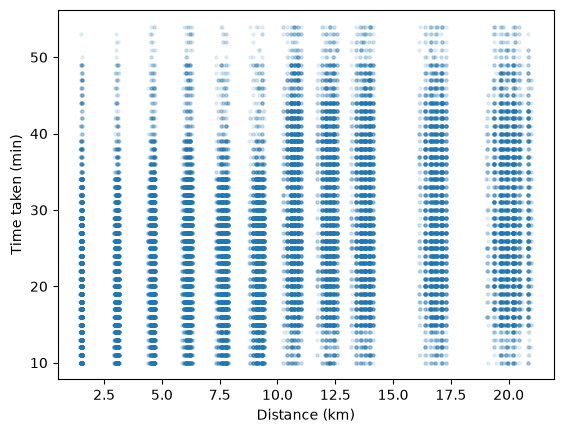

In [59]:
plt.scatter(df_clean['distance_km'], df_clean['Time_taken (min)'], alpha=0.1, s=5)
plt.xlabel('Distance (km)')
plt.ylabel('Time taken (min)')
plt.show()

In [71]:
df_clean['order_hour'] = pd.to_datetime(df_clean['Time_Orderd'], format='%H:%M', errors='coerce').dt.hour

df_clean['order_hour'].value_counts().sort_index()

order_hour
8.0     1746
9.0     1694
10.0    1708
11.0    1696
12.0     703
13.0     704
14.0     717
15.0     787
16.0     656
17.0    4211
18.0    4077
19.0    4169
20.0    4089
21.0    4276
22.0    4172
23.0    4089
Name: count, dtype: int64

In [72]:
df_clean.groupby('order_hour')['Road_traffic_density'].value_counts(normalize=True).unstack()

Road_traffic_density,Jam,High,Medium,Low
order_hour,,,,
8.0,NaN,NaN,NaN,1.0
9.0,NaN,NaN,NaN,1.0
10.0,NaN,NaN,NaN,1.0
11.0,NaN,1.0,NaN,NaN
12.0,NaN,1.0,NaN,NaN
13.0,NaN,1.0,NaN,NaN
14.0,NaN,1.0,NaN,NaN
15.0,NaN,NaN,1.0,NaN
16.0,NaN,NaN,1.0,NaN


In [73]:
df_clean.groupby('order_hour')['Weather_conditions'].value_counts(normalize=True).unstack()

Weather_conditions,Cloudy,Fog,Sandstorms,Stormy,Sunny,Windy
order_hour,,,,,,
8.0,0.166094,0.164948,0.170103,0.187285,0.153494,0.158076
9.0,0.171783,0.174144,0.167651,0.164109,0.158205,0.164109
10.0,0.149883,0.166276,0.165691,0.180328,0.179742,0.158080
11.0,0.171580,0.182193,0.158608,0.167453,0.159788,0.160377
12.0,0.163585,0.170697,0.169275,0.159317,0.169275,0.167852
13.0,0.164773,0.149148,0.149148,0.164773,0.184659,0.187500
14.0,0.158996,0.182706,0.160391,0.165969,0.178522,0.153417
15.0,0.170267,0.165184,0.174079,0.167726,0.157560,0.165184
16.0,0.170732,0.189024,0.167683,0.173780,0.137195,0.161585


In [74]:
df_clean.groupby('order_hour')['Road_traffic_density'].nunique()

order_hour
8.0     1
9.0     1
10.0    1
11.0    1
12.0    1
13.0    1
14.0    1
15.0    1
16.0    1
17.0    1
18.0    1
19.0    1
20.0    1
21.0    1
22.0    1
23.0    1
Name: Road_traffic_density, dtype: int64

In [75]:
df_clean.groupby('City')['Weather_conditions'].value_counts(normalize=True).unstack()

Weather_conditions,Cloudy,Fog,Sandstorms,Stormy,Sunny,Windy
City,,,,,,
Metropolitian,0.171807,0.175040,0.166088,0.168513,0.151805,0.166747
Semi-Urban,0.288344,0.202454,0.122699,0.122699,0.122699,0.141104
Urban,0.154195,0.155809,0.168213,0.170129,0.192416,0.159238


In [76]:
df_clean['City'].value_counts()

City
Metropolitian    33868
Urban            10033
Semi-Urban         164
Name: count, dtype: int64

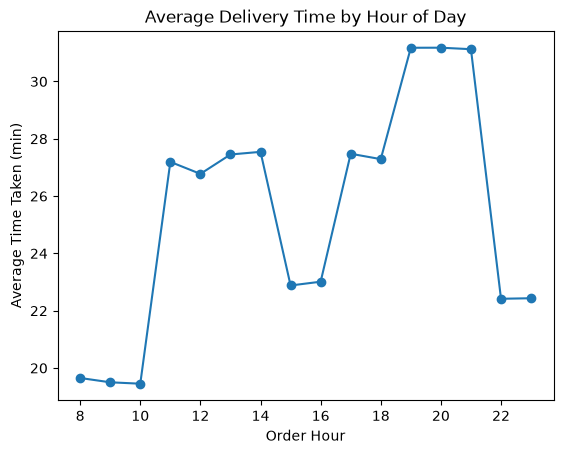

In [77]:
hourly_avg = df_clean.groupby('order_hour')['Time_taken (min)'].mean()

plt.plot(hourly_avg.index, hourly_avg.values, marker='o')
plt.xlabel('Order Hour')
plt.ylabel('Average Time Taken (min)')
plt.title('Average Delivery Time by Hour of Day')
plt.show()

In [78]:
df_clean['Time_taken (min)'].skew()

np.float64(0.4828568833512228)